In [2]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb
import glob 

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

c:\Users\hetpe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Step 1: merge all the participant files from 1C

In [3]:
folder_path = "dfs_per_participant"
files = glob.glob(f"{folder_path}/*csv") #get name of all files in folder

dataframes = [] #list of all dataframes
for file in files:
    print('loading:', file)
    df = pd.read_csv(file)
    dataframes.append(df)
full_df = pd.concat(dataframes, ignore_index=True) #merge the dataframes


loading: dfs_per_participant\df_AS14.01.csv
loading: dfs_per_participant\df_AS14.02.csv
loading: dfs_per_participant\df_AS14.03.csv
loading: dfs_per_participant\df_AS14.05.csv
loading: dfs_per_participant\df_AS14.06.csv
loading: dfs_per_participant\df_AS14.07.csv
loading: dfs_per_participant\df_AS14.12.csv
loading: dfs_per_participant\df_AS14.13.csv
loading: dfs_per_participant\df_AS14.14.csv
loading: dfs_per_participant\df_AS14.15.csv
loading: dfs_per_participant\df_AS14.16.csv
loading: dfs_per_participant\df_AS14.19.csv
loading: dfs_per_participant\df_AS14.23.csv
loading: dfs_per_participant\df_AS14.24.csv
loading: dfs_per_participant\df_AS14.25.csv
loading: dfs_per_participant\df_AS14.27.csv
loading: dfs_per_participant\df_AS14.28.csv
loading: dfs_per_participant\df_AS14.29.csv
loading: dfs_per_participant\df_AS14.30.csv
loading: dfs_per_participant\df_AS14.32.csv
loading: dfs_per_participant\df_AS14.33.csv


In [4]:
# avg_mood_target is the target value

full_df

,id,t,avg_mood_t,std_mood_t,trend_mood_t,avg_valence_t,std_valence_t,trend_valence_t,avg_arousal_t,std_arousal_t,trend_arousal_t,avg_screen_t,std_screen_t,trend_screen_t,target_day,avg_mood_target,std_mood_target,trend_mood_target
0,AS14.01,day 1-5,6.409091,0.650810,0.022021,0.545455,0.582102,0.009034,0.181818,0.935966,0.044043,89.034294,202.542435,-0.410834,day 6,6.00,0.632456,1.000000e-01
1,AS14.01,day 2-6,6.347826,0.698364,-0.007905,0.391304,0.641949,-0.005929,0.391304,1.010343,0.034585,84.608197,186.752398,-0.155268,day 7,6.75,0.829156,1.000000e-01
2,AS14.01,day 3-7,6.416667,0.759203,0.006087,0.416667,0.640095,-0.004348,0.458333,0.911920,0.015217,100.623293,264.562798,0.051103,day 8,6.60,0.489898,-1.755417e-17
3,AS14.01,day 4-8,6.500000,0.763763,0.000000,0.500000,0.645497,-0.010435,0.375000,1.033300,-0.029130,90.594911,260.016018,0.122897,day 9,7.00,0.000000,0.000000e+00
4,AS14.01,day 5-9,6.625000,0.695971,0.018696,0.541667,0.575845,0.010000,0.291667,1.059841,-0.025652,105.269426,394.646605,0.095235,day 10,6.40,1.019804,4.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,AS14.33,day 34-38,5.916667,1.351440,-0.006957,0.208333,0.762625,-0.001304,-0.458333,1.117257,-0.025652,162.455530,600.103896,0.527627,day 39,6.20,0.748331,1.000000e-01
837,AS14.33,day 35-39,6.000000,1.232883,-0.002308,0.240000,0.763151,0.010000,-0.640000,1.162067,0.017692,163.511837,603.448546,0.284473,day 40,8.20,1.469694,-9.000000e-01
838,AS14.33,day 36-40,6.500000,1.527525,0.070435,0.500000,0.816497,0.028696,-0.458333,1.322219,0.023913,144.670648,547.701681,0.038452,day 41,7.00,0.000000,0.000000e+00
839,AS14.33,day 37-41,6.590909,1.466570,0.098814,0.590909,0.778056,0.046866,-0.545455,1.304791,-0.009034,139.848583,574.597519,0.097955,day 42,6.80,0.979796,3.510833e-17


Step 3; split train/test set in a time-aware way
Since our rows are sequential windows per patient, the split should respect time and avoid training on future rows while testing on earlier ones. What “time-aware split” means here. For each participant separately: take the earlier rows for training, take the later rows for testing. Then do that for every participant, and combine all participant-level train parts into one training set and all test parts into one test set.

In [5]:
train_parts = [] #early data
test_parts = [] #later data
split_value = 0.8

for partcipant_id, group in full_df.groupby('id'):  #split dataset into groups based on id
    group = group.sort_values('target_day') #sort by target day
    split_idx = int(len(group) * split_value) #decide where to split
    
    train_group = group.iloc[:split_idx]
    test_group = group.iloc[split_idx:]

    train_parts.append(train_group)
    test_parts.append(test_group)

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

step 4; removing target leakage columns.
Target leakage = giving the model information it should not have at prediction time. As we try to predict next-day mood, the model should only see information from the past (window). Not anything from the target day. therefore we remove the target features from the dataframe, so we remove avg_mood_target, std_mood_target, trend_mood_target from the features. Additionally we remove id, t, and target_day as features.

In [7]:
cols_to_drop = [
#mood_class is not here
    "avg_mood_target",     # leakage
    "std_mood_target",     # leakage
    "trend_mood_target",   # leakage
    "id",                  # not a feature
    "t",                   # not useful
    "target_day"           # future info
]

X_train = train_df.drop(columns=cols_to_drop) #training features
y_train = train_df["avg_mood_target"]

X_test = test_df.drop(columns=cols_to_drop) #same as training features
y_test = test_df["avg_mood_target"]

print(X_train.shape)
print(y_train.shape)


(664, 12)
(664,)


Train a first random forest:


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42) #to make the results reproducible
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

make predictions

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred)) # average squared error, penalizes large errors
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) # same unit as target?
print("MAE:", mean_absolute_error(y_test, y_pred)) # average absolut error, robust to outliers
print("R squared:", r2_score(y_test, y_pred)) # how much variance is explained, 1.0 = perfect

MSE: 0.48871572598870083
RMSE: 0.6990820595528832
MAE: 0.47670056497175145
R squared: 0.2233157345400335


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {"n_estimators": [100, 200], "max_depth": [5, 10, None],}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3, #Use 3-fold cross-validation
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 5, 'n_estimators': 200}
-0.49706044788699516


In [12]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred)) # average squared error, penalizes large errors
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) # same unit as target?
print("MAE:", mean_absolute_error(y_test, y_pred)) # average absolut error, robust to outliers
print("R squared:", r2_score(y_test, y_pred)) # how much variance is explained, 1.0 = perfect

MSE: 0.4720445389951369
RMSE: 0.6870549752349785
MAE: 0.47039956997117344
R squared: 0.24981017279091422


In [14]:
print(y_test.shape)
print(y_pred.shape)

(177,)
(177,)


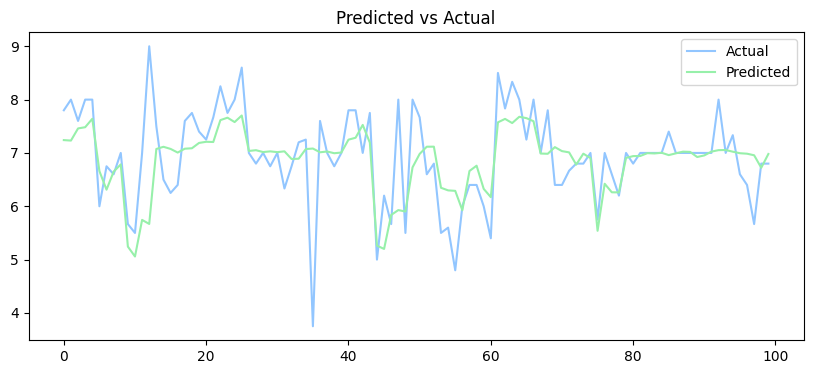

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual')
plt.show()